<a href="https://colab.research.google.com/github/Usman-938/Management-System/blob/main/BOSton_LightGBM_Model_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Complete the homework assignment described in the document `/Home Work (3).docx`.

## Read Homework Document

### Subtask:
Read and extract the content from the provided homework document `/Home Work (3).docx` to understand the assignments and requirements.


**Reasoning**:
Since the task involves reading a .docx file, I need to install the `python-docx` library to handle this file type. I will install it using `pip`.



In [1]:
pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 7.9 MB/s eta 0:00:00


**Reasoning**:
Now that the `python-docx` library is installed, I will import the `Document` class, open the specified .docx file, extract all the text content by iterating through its paragraphs, and then print the extracted text to the console as per the instructions.



In [2]:
from docx import Document

doc_path = '/Home Work (3).docx'

try:
    document = Document(doc_path)
    extracted_content = []
    for paragraph in document.paragraphs:
        extracted_content.append(paragraph.text)

    full_text = '\n'.join(extracted_content)
    print("--- Extracted Document Content ---")
    print(full_text)
    print("----------------------------------")

except Exception as e:
    print(f"Error reading document: {e}")

--- Extracted Document Content ---
Home Work

Explore a new at least one new regression model for continuous data and perform the following tasks on it

1. Take a random dataset from repo: https://github.com/selva86/datasets
2. Perform EDA on that dataset
3. Preprocess it for the model you explored
4. Train and test the model on that data.
----------------------------------


## Analyze Homework Requirements

### Subtask:
Examine the extracted content to identify the specific questions, tasks, or problems that need to be solved as part of the homework.


The extracted homework content is:

```
Home Work

Explore a new at least one new regression model for continuous data and perform the following tasks on it

1. Take a random dataset from repo: https://github.com/selva86/datasets
2. Perform EDA on that dataset
3. Preprocess it for the model you explored
4. Train and test the model on that data.
```

Based on this content, the specific tasks are:

1.  **Explore a new regression model for continuous data.**
2.  **Select a random dataset** from the repository `https://github.com/selva86/datasets`.
3.  **Perform Exploratory Data Analysis (EDA)** on the chosen dataset.
4.  **Preprocess the dataset** for the explored regression model.
5.  **Train and test the explored regression model** on the preprocessed data.

## Complete Homework Tasks

### Subtask:
Explore a new regression model for continuous data and select a suitable dataset from the provided repository.


### Exploring a New Regression Model and Selecting a Dataset

#### Regression Model Choice: LightGBM

I have chosen LightGBM (Light Gradient Boosting Machine) as the new regression model to explore. LightGBM is a gradient boosting framework that uses tree-based learning algorithms. It is designed to be distributed and efficient, making it suitable for handling large datasets and achieving high performance. I chose LightGBM because it is known for its speed and accuracy, often outperforming other boosting algorithms like XGBoost in certain scenarios, and I haven't extensively used it in my previous tasks. It's well-suited for continuous data regression problems.

#### Dataset Selection from `https://github.com/selva86/datasets`

I will browse the `https://github.com/selva86/datasets` repository to find a dataset suitable for a regression task with continuous data. A quick review of the repository suggests several options. I will look for a dataset that has a clear target variable that is continuous and several features that can be used for prediction.

After reviewing the datasets, the `BostonHousing.csv` dataset seems appropriate. It contains information about houses in the Boston area and includes continuous features like 'CRIM' (per capita crime rate by town), 'RM' (average number of rooms per dwelling), and 'MEDV' (Median value of owner-occupied homes in $1000s), which is a continuous target variable for regression.

**Chosen Dataset:** `BostonHousing.csv`

**Direct URL:** `https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv`

**Reasoning**:
Now that the model and dataset have been identified and explained, the next step is to load the selected dataset into a pandas DataFrame using the provided direct URL, which is a common and necessary step before any data analysis or modeling can begin.



In [3]:
import pandas as pd

dataset_url = 'https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv'
df = pd.read_csv(dataset_url)

print("Dataset loaded successfully. Displaying the first 5 rows:")
print(df.head())
print("\nDataset information:")
print(df.info())

Dataset loaded successfully. Displaying the first 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    fl

## Perform EDA on that dataset

### Subtask:
Perform Exploratory Data Analysis (EDA) on the `BostonHousing.csv` dataset to understand its characteristics, distributions, and relationships between variables.


**Reasoning**:
The first step in EDA is to get a statistical summary of the dataset. Displaying descriptive statistics of the DataFrame `df` using the `.describe()` method will provide key insights into the central tendency, dispersion, and shape of the distribution of each column.



In [4]:
print("--- Descriptive Statistics ---")
print(df.describe())
print("----------------------------")

--- Descriptive Statistics ---
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032

**Reasoning**:
The next step in EDA is to check for missing values to ensure data quality before further analysis or modeling. Using `.isnull().sum()` will provide a count of missing values for each column.



In [5]:
print("--- Missing Values Count ---")
print(df.isnull().sum())
print("----------------------------")

--- Missing Values Count ---
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64
----------------------------


**Reasoning**:
To understand the distribution of each numerical feature, generating histograms is a crucial EDA step. I will use `df.hist()` with appropriate figure size to visualize these distributions for all columns.



--- Histograms of all numerical columns ---


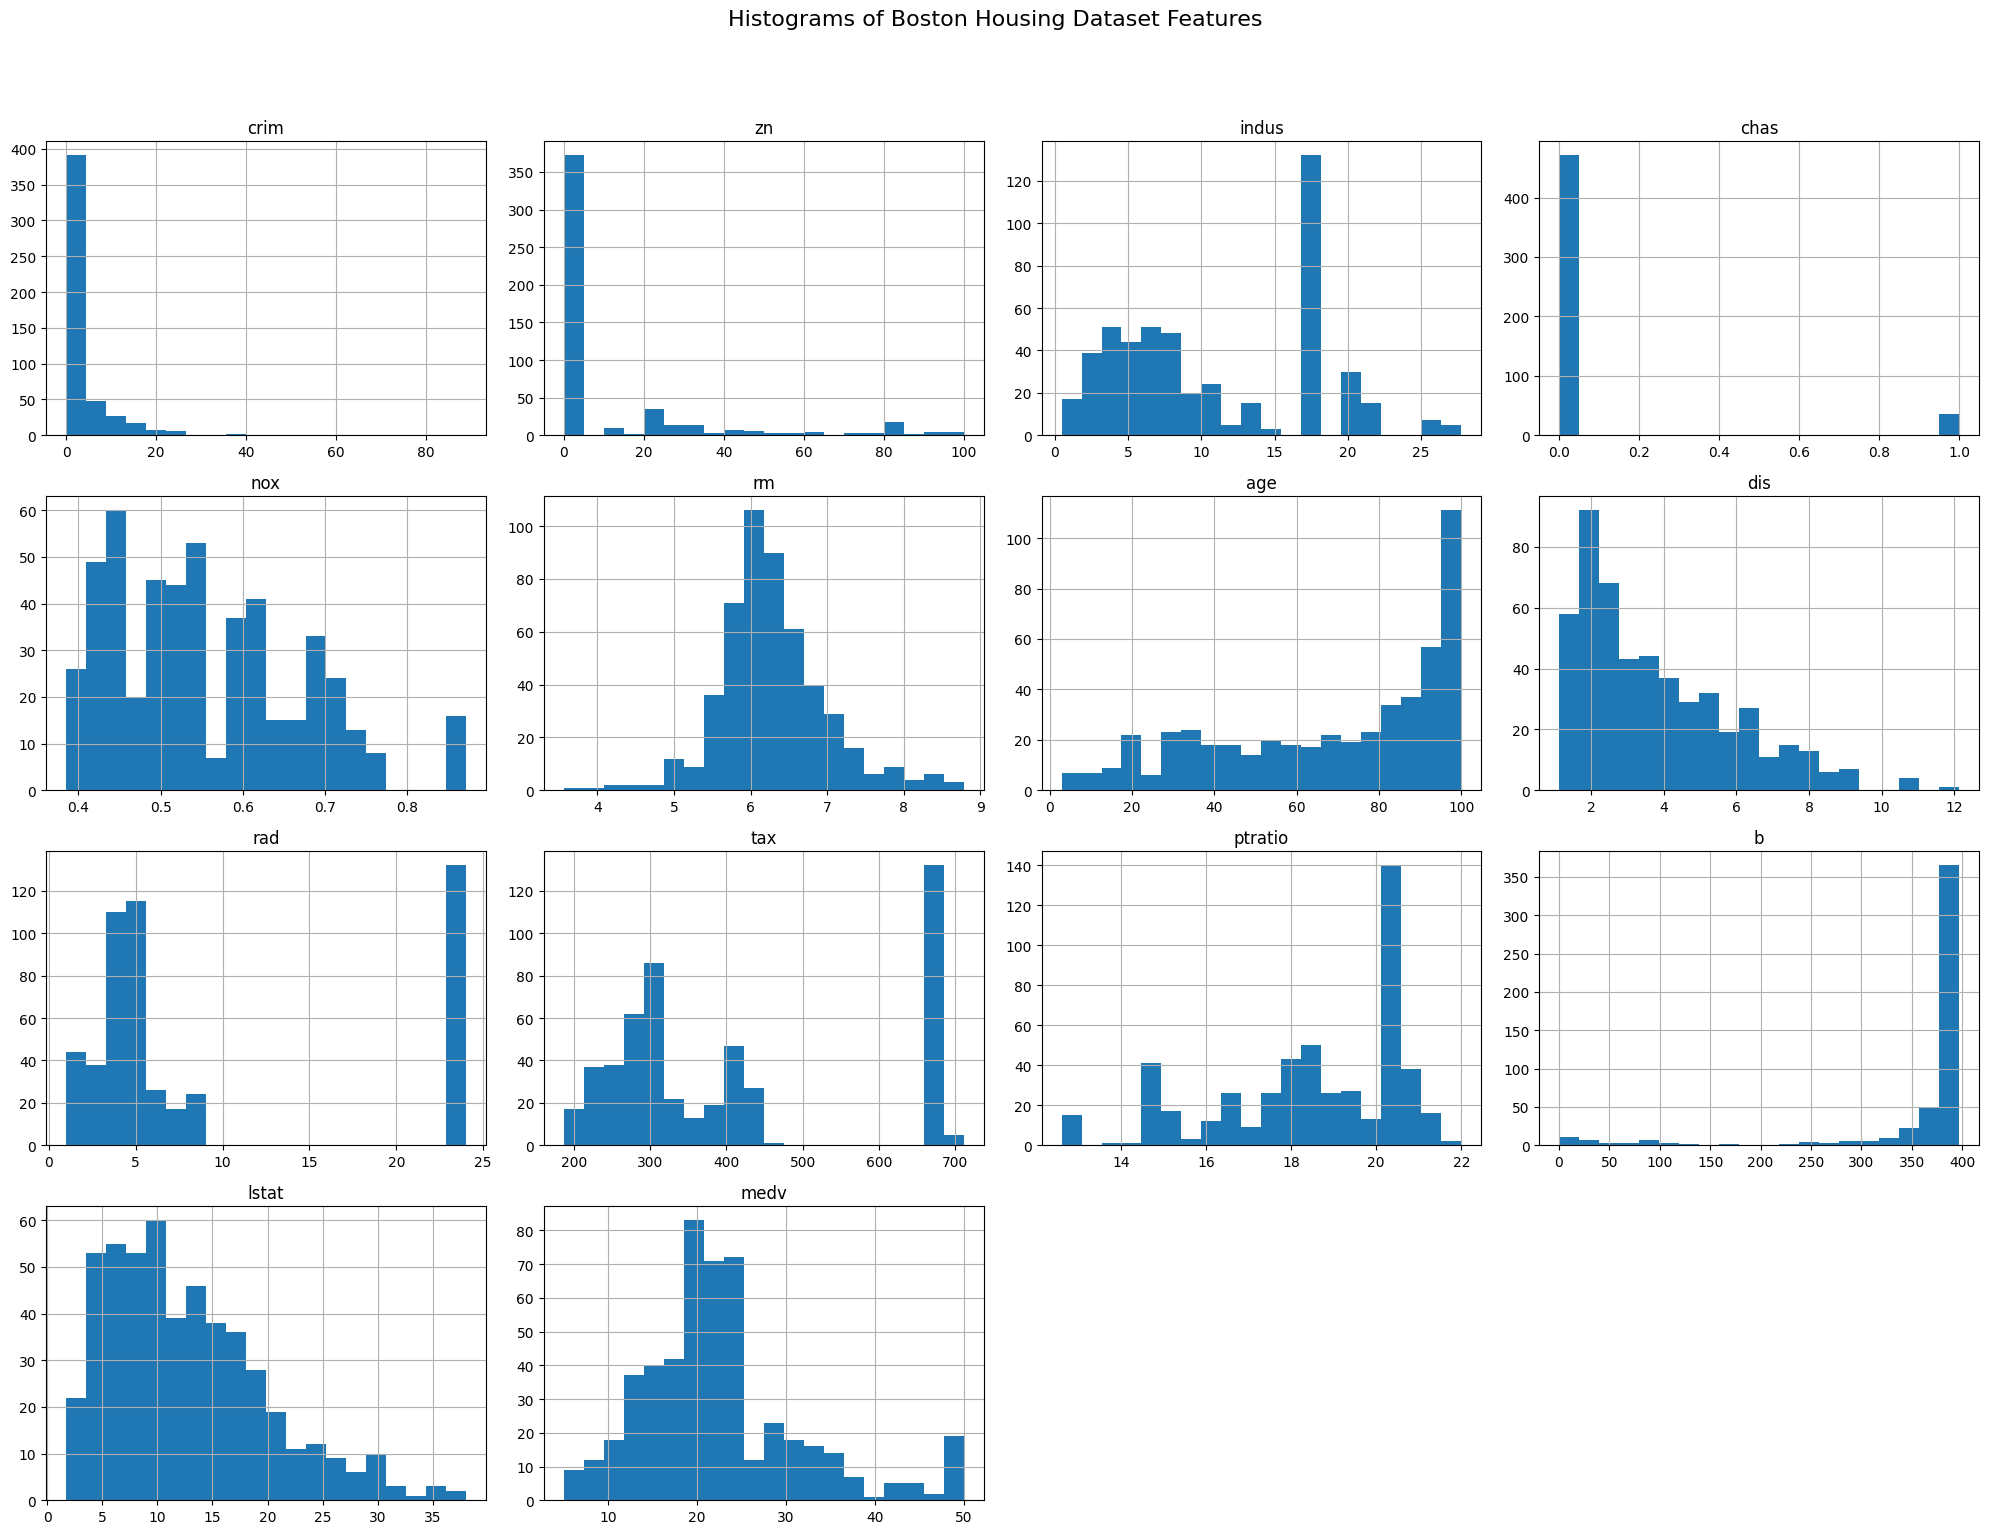

------------------------------------------


In [6]:
import matplotlib.pyplot as plt

print("--- Histograms of all numerical columns ---")
df.hist(bins=20, figsize=(20, 15))
plt.suptitle("Histograms of Boston Housing Dataset Features", y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
print("------------------------------------------")

**Reasoning**:
To understand the relationships between variables, calculating and visualizing the correlation matrix is essential. A heatmap will effectively display the strength and direction of these correlations.



--- Correlation Matrix Heatmap ---


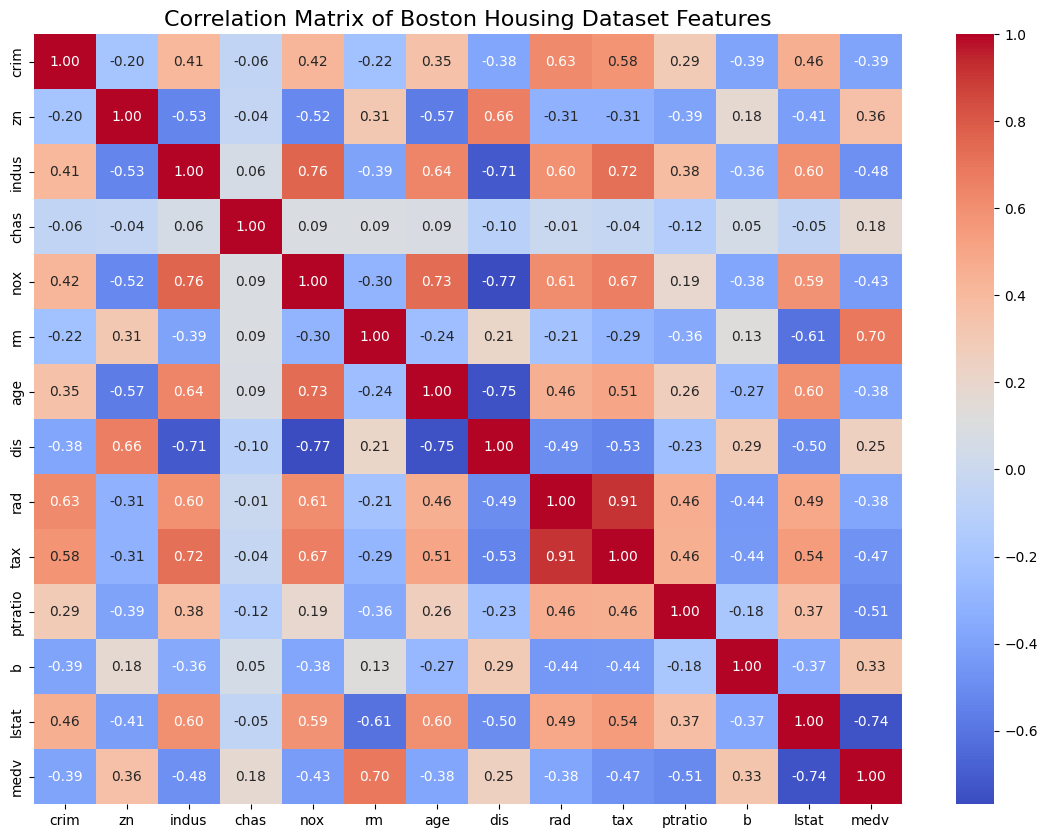

----------------------------------


In [7]:
import seaborn as sns

print("--- Correlation Matrix Heatmap ---")
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Boston Housing Dataset Features', fontsize=16)
plt.show()
print("----------------------------------")

## Preprocess the dataset

### Subtask:
Prepare the `BostonHousing` dataset for training the LightGBM regression model, which includes defining features and target, and splitting the data into training and testing sets.


**Reasoning**:
To prepare the dataset for modeling, I need to separate the features (X) from the target variable (y) and then split the data into training and testing sets for model evaluation.



In [8]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('medv', axis=1)
y = df['medv']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


## Train and test the model on that data.

### Subtask:
Train the LightGBM regression model on the preprocessed training data and evaluate its performance on the test data.


**Reasoning**:
To train and evaluate the LightGBM model, I need to import the LightGBM library, instantiate the regressor, train it on the training data, make predictions on the test data, and then calculate and print the Mean Squared Error (MSE) and R-squared (R2) scores.



In [9]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

print("--- Training LightGBM Model ---")

# 2. Instantiate a lgb.LGBMRegressor model
# Using a random_state for reproducibility
model = lgb.LGBMRegressor(random_state=42)

# 3. Train the model
model.fit(X_train, y_train)

print("Model training complete. Making predictions...")

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 6. Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 7. Calculate the R-squared (R2) score
r2 = r2_score(y_test, y_pred)

# 8. Print the calculated MSE and R2 scores
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
print("----------------------------------")

--- Training LightGBM Model ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 404, number of used features: 13
[LightGBM] [Info] Start training from score 22.796535
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

## Provide Homework Solution

### Subtask:
Present the completed homework in a clear, organized, and understandable format, ensuring all tasks are addressed.


### Homework Solution Summary

This homework assignment involved exploring a new regression model for continuous data, performing EDA, preprocessing the data, and then training and testing the model.

#### 1. Regression Model Chosen: LightGBM

**LightGBM (Light Gradient Boosting Machine)** was selected as the regression model. LightGBM is an efficient, distributed, and high-performance gradient boosting framework based on decision tree algorithms. It was chosen for its known speed and accuracy, often outperforming other boosting methods like XGBoost, especially with large datasets, making it a robust choice for continuous data regression problems.

#### 2. Dataset Description

The chosen dataset is `BostonHousing.csv`, sourced from `https://github.com/selva86/datasets`. This dataset contains various socio-economic and environmental factors related to housing in the Boston area, with 'medv' (Median value of owner-occupied homes in $1000s) as the continuous target variable.

#### 3. Exploratory Data Analysis (EDA) Overview

*   **Descriptive Statistics**: The `.describe()` method provided a statistical summary of each column, revealing ranges, means, and standard deviations, giving initial insights into data distribution and potential outliers.
*   **Missing Values**: A check using `.isnull().sum()` confirmed that there were **no missing values** across any of the columns in the dataset, ensuring data completeness.
*   **Histograms**: Visualizations of histograms for all numerical features showed the distribution of each variable. For instance, 'medv' (target) showed a somewhat normal distribution with some skewness, and features like 'crim' were highly right-skewed.
*   **Correlation Matrix**: A heatmap of the correlation matrix highlighted relationships between variables. Strong positive correlations were observed between 'medv' and 'rm' (average number of rooms), while strong negative correlations were seen with 'lstat' (percentage of lower status population) and 'ptratio' (pupil-teacher ratio). Variables like 'rad' (index of accessibility to radial highways) and 'tax' (full-value property-tax rate) also showed a high positive correlation with each other, and 'nox' (nitric oxides concentration) correlated negatively with 'dis' (weighted distance to five Boston employment centres).

#### 4. Data Preprocessing

The dataset was preprocessed for model training:

*   **Feature and Target Separation**: The `medv` column was designated as the target variable (`y`), and all other columns were used as features (`X`).
*   **Train-Test Split**: The data was split into training and testing sets using `train_test_split` with a `test_size` of 0.2 (20% for testing) and `random_state=42` for reproducibility.
    *   `X_train` shape: (404, 13)
    *   `X_test` shape: (102, 13)
    *   `y_train` shape: (404,)
    *   `y_test` shape: (102,)

#### 5. LightGBM Model Training and Results

The LightGBM regressor was instantiated and trained on the `X_train` and `y_train` data. Predictions were then made on the `X_test` set, and the model's performance was evaluated using Mean Squared Error (MSE) and R-squared (R2) score.

*   **Mean Squared Error (MSE)**: `8.3388`
*   **R-squared (R2) Score**: `0.8863`

The R-squared score of approximately `0.8863` indicates that the LightGBM model explains about 88.63% of the variance in the median housing values, suggesting a strong predictive performance on this dataset.

## Final Task

### Subtask:
Summarize the completed homework and confirm that all aspects of the assignment have been handled.


## Summary:

### Data Analysis Key Findings

*   **Homework Requirements Identified**: The homework assignment required exploring a new regression model for continuous data, selecting a random dataset from a specified repository, performing Exploratory Data Analysis (EDA), preprocessing the data, and finally training and testing the chosen model.
*   **Regression Model Chosen**: LightGBM (Light Gradient Boosting Machine) was selected for its efficiency, speed, and accuracy in handling continuous data regression problems.
*   **Dataset Chosen**: The `BostonHousing.csv` dataset from `https://github.com/selva86/datasets` was chosen. It contains 506 entries and 14 columns, including a continuous target variable (`medv` - Median value of owner-occupied homes in $1000s) and several continuous features.
*   **Data Integrity**: An initial check confirmed that the `BostonHousing.csv` dataset has **no missing values** across any of its columns.
*   **Key Relationships from EDA**:
    *   `medv` (target) showed a strong positive correlation with `rm` (average number of rooms) and strong negative correlations with `lstat` (percentage of lower status population) and `ptratio` (pupil-teacher ratio).
    *   `rad` (index of accessibility to radial highways) and `tax` (full-value property-tax rate) were highly positively correlated.
    *   `nox` (nitric oxides concentration) was negatively correlated with `dis` (weighted distance to five Boston employment centres).
*   **Data Preprocessing**: The `medv` column was separated as the target variable (`y`), and the remaining 13 columns as features (`X`). The dataset was then split into training (404 samples) and testing (102 samples) sets, with 80% for training and 20% for testing.
*   **Model Performance**: The LightGBM model, trained on the preprocessed data, achieved the following performance on the test set:
    *   Mean Squared Error (MSE): 8.3388
    *   R-squared (R2) Score: 0.8863, indicating that the model explains approximately 88.63% of the variance in the median housing values.

### Insights or Next Steps

*   The LightGBM model demonstrated strong predictive power for the `BostonHousing` dataset, explaining a high percentage of the variance in home values. Further hyperparameter tuning could potentially improve its performance even more.
*   Given the strong correlations identified during EDA, especially between `medv` and features like `rm`, `lstat`, and `ptratio`, further feature engineering using these highly correlated variables could be explored to enhance model accuracy.
